# Hantavirus network 
This code will create a network graph (Conversational Network) for bluesky data on the hantavirus 

---
### Import data and Libraries

In [3]:
#Import all required libraries
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import community as community_louvain

In [4]:
#Load the data
graph_df = pd.read_csv("combined_hantavirus_clean.csv")

#Fill Missing replying_to columns as ROOT
#This is missing for root posts (not a reply or comment)
graph_df["replying_to"] = graph_df["replying_to"].fillna("ROOT")

#Drop all null values and ensure data is in correct type
graph_df = graph_df.dropna(subset=["author", "replying_to", "depth"])
graph_df = graph_df.astype({"author": str, "replying_to": str, "depth": int})

In [5]:
#View the data to ensure it has been correctly imported
graph_df

,uri,author,replying_to,text,created_at,depth,likes,reposts
0,at://did:plc:jt7gzhduaswkv52mqq4phye6/app.bsky...,mrhappyonbsky.eurosky.social,dietagespresse.com,😂🤣 and so it begins ..........,2026-05-11T15:06:01.095Z,1,0,0
1,at://did:plc:rumwkx7xd3dcbsp3e4i3ptwh/app.bsky...,cyberbadboy.com,ROOT,Hantavirus is no joke 😂\n\nThat's why I've sta...,2026-05-11T14:24:49.316Z,0,1963,242
2,at://did:plc:xsxjfbeakywwtkml5q5lhcrc/app.bsky...,freecialis.bsky.social,cyberbadboy.com,holy privilege batman. most working class peop...,2026-05-11T15:20:48.286Z,1,106,1
3,at://did:plc:xhoys6noboked2gnfi27pxnt/app.bsky...,kloudkat.bsky.social,cyberbadboy.com,Downloading the Hentaivirus off KissAnime to t...,2026-05-11T15:23:52.102Z,1,2,0
4,at://did:plc:xcvngmugzz7owrg4pz4qzowt/app.bsky...,greavesoflass.bsky.social,cyberbadboy.com,I've started masking when I go out to a rat fe...,2026-05-11T14:54:06.021Z,1,41,0
...,...,...,...,...,...,...,...,...
8479,at://did:plc:cc5vrng7rf2zerek6xh7bhll/app.bsky...,njbbari3.bsky.social,melhathnofury.bsky.social,Only if he is infected… and had a decent virae...,2026-05-09T06:28:48.427Z,4,5,1
8480,at://did:plc:7m6olqbqf6upax5hjwfldyvd/app.bsky...,musictplove.bsky.social,thecovidinfoguy.bsky.social,Meanwhile the US keeps putting lives at risk. ...,2026-05-09T05:48:08.196Z,1,9,5
8481,at://did:plc:3bd6p7ah522kteulpx2zvxus/app.bsky...,charitychicken.bsky.social,thecovidinfoguy.bsky.social,"JFC, of course. 🤦‍♀️",2026-05-09T02:32:05.869Z,1,9,0
8482,at://did:plc:viflamzasnec2prd3b7y2yg5/app.bsky...,crof.bsky.social,ROOT,"Hantavirus, COVID, norovirus, legionnaires’: w...",2026-05-09T19:50:45.639Z,0,14,13


---
### Build directed & Weighted Graph

In [7]:
#Code adapted from wk8 lab
#Build mappings
id2author = dict(zip(graph_df["uri"], graph_df["author"]))

#Infer root post author from commentsreplies where depth == 0
thread2author = dict(graph_df[graph_df["depth"] == 0].groupby("uri")["author"].first())

#Count identifiable posts per author
post_counts = pd.Series(thread2author).value_counts().to_dict()


In [8]:
#Output the users with the most posts
post_counts

{'reuters.com': 15,
 'thev.bsky.social': 12,
 'nytimes.com': 12,
 'theguardian.com': 11,
 'apnews.com': 9,
 'thecovidinfoguy.bsky.social': 8,
 'cnn.com': 7,
 'chantzy.bsky.social': 7,
 'pbsnews.org': 6,
 'realtuckfrumper.bsky.social': 6,
 'plaguepoems.bsky.social': 6,
 'nbcnews.com': 5,
 'canadahealthwatch.ca': 5,
 'aljazeera.com': 5,
 'krutikakuppalli.bsky.social': 4,
 'who.int': 4,
 'datareport.bsky.social': 4,
 'davidbflower.bsky.social': 4,
 'bloomberg.com': 4,
 'covid19disease.bsky.social': 4,
 'mackayim.bsky.social': 4,
 'thebulwark.com': 3,
 'cwebbonline.com': 3,
 'gavinyamey.bsky.social': 3,
 'onestpress.onestnetwork.com': 3,
 'mjfree.bsky.social': 3,
 'saltybitchables.bsky.social': 3,
 'ylepidemiologist.bsky.social': 3,
 'cidrap.bsky.social': 3,
 'bladeofthes.bsky.social': 3,
 'nature.com': 3,
 'bbcnews-world-rss.bsky.social': 3,
 'aaronparnas.bsky.social': 3,
 'minibubbly.bsky.social': 3,
 'thedailyshow.com': 3,
 'meidastouch.com': 3,
 'billmccarthy.bsky.social': 2,
 'thegods

In [9]:
#Code adapted from wk8 lab
#Create a directed weighted graph
#Direction is who replied to who
#Weight is how many interactions of that direction
replyGraph = nx.DiGraph()

#Add user nodes with postNum
for user in graph_df["author"].unique():
    replyGraph.add_node(user,postNum=int(post_counts.get(user, 0)))

#Add directed weighted reply edges
for _, row in graph_df.iterrows():
    user = row["author"]
    parent_id = row["replying_to"]

    #Determine if post is original post
    #We do not want to include root posts as a reply to a root post
    if parent_id == 'ROOT':
        parent_user = user

    #Replies to post or another reply
    else:
        parent_user = parent_id

    #Add edge: user -> parent_user
    if parent_user and parent_user != user:
        if replyGraph.has_edge(user, parent_user):
            replyGraph[user][parent_user]["replyNum"] += 1
        else:
            replyGraph.add_edge(user, parent_user, replyNum=1)

#Check graph
print("Nodes:", replyGraph.number_of_nodes())
print("Edges:", replyGraph.number_of_edges())

#Save the graph to a file
nx.write_graphml(replyGraph, "HV_reply_graph.graphml")

Nodes: 5478
Edges: 6845


---
### Centrality

In [11]:
#Code adapted from wk8 lab
sFileName = "HV_reply_graph.graphml"

#Reading file back in
replyGraph = nx.readwrite.read_graphml(sFileName)

#Computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(replyGraph)

#Computing the Eigenvector centrality and plotting it
lEigenVectorCentrality = nx.eigenvector_centrality(replyGraph, max_iter=5000)

#Computing the Katz centrality and plotting it
lKatzCentrality = nx.katz_centrality(replyGraph, alpha=0.01, max_iter=5000)

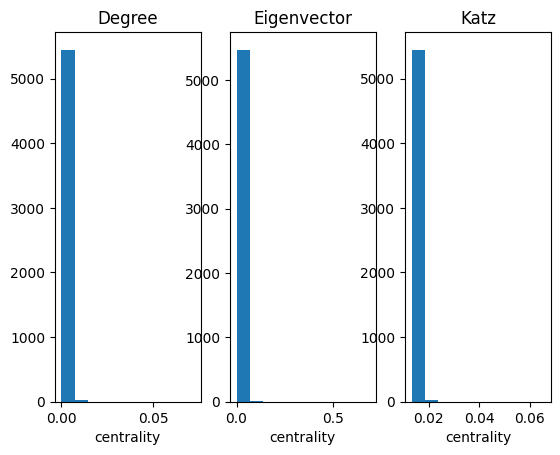

In [12]:
#Code adapted from wk8 lab
#Plot histograms for centrality measures
#Degree centrality
plt.subplot(1,3,1)
plt.hist(list(lDegCentrality.values()))
plt.title('Degree')
plt.xlabel('centrality')
#Eigenvector centrality
plt.subplot(1, 3, 2)
plt.hist(list(lEigenVectorCentrality.values()))
plt.title('Eigenvector')
plt.xlabel('centrality')
#Katz centrality
plt.subplot(1, 3, 3)
plt.hist(list(lKatzCentrality.values()))
plt.title('Katz')
plt.xlabel('centrality')

plt.show()

In [13]:
#Code adapted from wk8 lab
#Update the node attributes with centrality
#Eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    replyGraph.nodes[nodeId]['eigen'] = float(cent)

#Katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    replyGraph.nodes[nodeId]['katz'] = float(cent)
    
#Write out graph to new file 
nx.readwrite.write_graphml(replyGraph, 'mod' + sFileName, infer_numeric_types=True)

#Compute and print clustering coefficient 
print('Gloabl clustering coefficient/transitivit = {}'.format(nx.transitivity(replyGraph)))

#Compute and print components (weak and strong)
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(replyGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(replyGraph)))

#Compute and print bridges
print(list(nx.bridges(replyGraph.to_undirected())))

Gloabl clustering coefficient/transitivit = 0.021920233260439445
number of strongly connected components = 4838
number of weakly connected components = 249
[('mrhappyonbsky.eurosky.social', 'dietagespresse.com'), ('cyberbadboy.com', 'freecialis.bsky.social'), ('cyberbadboy.com', 'kloudkat.bsky.social'), ('cyberbadboy.com', 'greavesoflass.bsky.social'), ('cyberbadboy.com', 'monstersnowgoon.bsky.social'), ('cyberbadboy.com', 'jasonthee.bsky.social'), ('cyberbadboy.com', 'c2snow.bsky.social'), ('cyberbadboy.com', 'bflmouse.bsky.social'), ('cyberbadboy.com', 'halibut.bsky.social'), ('cyberbadboy.com', 'joodburn.bsky.social'), ('cyberbadboy.com', 'possumacquainter.bsky.social'), ('cyberbadboy.com', 'stewieeee.bsky.social'), ('cyberbadboy.com', 'saturnvf1.bsky.social'), ('cyberbadboy.com', 'rowzat.bsky.social'), ('cyberbadboy.com', 'warybear.bsky.social'), ('cyberbadboy.com', 'suannelqr.bsky.social'), ('cyberbadboy.com', 'crab.institute'), ('cyberbadboy.com', 'mnguy23.bsky.social'), ('cyberb

In [14]:
#Get the top 10 most central nodes (Eigenvector)
sortedEigen = sorted(lEigenVectorCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedEigen[:10])

[('raykwong.lol', 0.6902128520432677), ('trdowden2.bsky.social', 0.07659184095866796), ('merri24.bsky.social', 0.07523228674102085), ('thegopisfubar2024.bsky.social', 0.07508589098087869), ('dragonlady1011.bsky.social', 0.07508438684703375), ('bethtoja.bsky.social', 0.07508422321572174), ('sandiwi.bsky.social', 0.07508422321572174), ('inezsneks2024.bsky.social', 0.074360792553982), ('anonleeks.bsky.social', 0.06908357234183146), ('politicshealth.bsky.social', 0.06844184068961874)]


In [15]:
#Get the top 10 most central nodes (Katz)
sortedKatz = sorted(lKatzCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedKatz[:10])

[('cwebbonline.com', 0.06571496236359237), ('meidastouch.com', 0.06372916826639498), ('acyn.bsky.social', 0.047708691122196945), ('atrupar.com', 0.04415410050160769), ('thegodshow.com', 0.03747555202577947), ('muellershewrote.com', 0.03689277073412999), ('briantylercohen.bsky.social', 0.03550638836448305), ('raykwong.lol', 0.031391239908770754), ('kylegriffin1.bsky.social', 0.029953382190479876), ('thev.bsky.social', 0.02750035323964871)]


In [16]:
#Code adapted from: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html
#Calculating betweeness centrality for entire network
betweenness_dict = nx.betweenness_centrality(replyGraph, normalized=True)

#Output sorted betweness centrality scores (Highest -> Lowest)
sorted(betweenness_dict.items(), key=lambda x: x[1], reverse=True)

[('schimelsal.bsky.social', 0.010049615851242063),
 ('cwebbonline.com', 0.009820453154277896),
 ('ggareth.bsky.social', 0.009798933564132258),
 ('blueallylove.bsky.social', 0.009764506387670083),
 ('crys3.bsky.social', 0.009671836002862803),
 ('olau1.bsky.social', 0.009654656451426977),
 ('beneathacanopy.bsky.social', 0.009644418620036557),
 ('theonlyrealtmcmaui.bsky.social', 0.008096420884788859),
 ('raykwong.lol', 0.006341410512785805),
 ('andreastudiescovid.bsky.social', 0.005720269894932768),
 ('elizabethjacobs.bsky.social', 0.005348302139983796),
 ('seancj.bsky.social', 0.003932994477729429),
 ('reclaimingkaren.bsky.social', 0.0035631139227134986),
 ('mariablack.bsky.social', 0.0028512110301929247),
 ('mackayim.bsky.social', 0.002778367647858744),
 ('katiehowland.bsky.social', 0.002364027875441696),
 ('dj1au.bsky.social', 0.0023150648763161125),
 ('oldenaturalist.bsky.social', 0.002311026205604991),
 ('supermarina.bsky.social', 0.002112418697746009),
 ('tinni-tus.bsky.social', 0.0

---
### Community detection in graphs

In [18]:
#Code adapted from wk9 lab
#Detect communities in graphs
#Read the updated graph with centrality
G = nx.read_graphml("modHV_reply_graph.graphml")

#Louvain
partition = community_louvain.best_partition(G.to_undirected())
for node, comm_id in partition.items():
    G.nodes[node]["louvain"] = comm_id

#CPM
k = 3
cpm_comms = list(nx.algorithms.community.k_clique_communities(G.to_undirected(), k))
for i, comm in enumerate(cpm_comms):
    for node in comm:
        G.nodes[node]["cpm"] = i

#Write to a new graph
nx.write_graphml(G, "HV_communities.graphml")

---
#### Centrality Per Community

In [20]:
#Code adapted from: https://python-louvain.readthedocs.io/en/latest/api.html
#Assign each user to a community as per louvain method
#Graph must be undirected for this to work 
undirected_temp = replyGraph.to_undirected()
community_assign = community_louvain.best_partition(undirected_temp)
print(community_assign)

{'mrhappyonbsky.eurosky.social': 0, 'cyberbadboy.com': 1, 'freecialis.bsky.social': 1, 'kloudkat.bsky.social': 1, 'greavesoflass.bsky.social': 1, 'monstersnowgoon.bsky.social': 1, 'jasonthee.bsky.social': 1, 'c2snow.bsky.social': 1, 'bflmouse.bsky.social': 1, 'halibut.bsky.social': 1, 'joodburn.bsky.social': 1, 'possumacquainter.bsky.social': 1, 'lgbtqqip2saa.bsky.social': 2, 'stewieeee.bsky.social': 1, 'saturnvf1.bsky.social': 1, 'rowzat.bsky.social': 1, 'alexanderdudley.bsky.social': 1, 'warybear.bsky.social': 1, 'suannelqr.bsky.social': 1, 'crab.institute': 1, 'mnguy23.bsky.social': 1, 'craphammer.bsky.social': 1, 'decafbeef.bsky.social': 1, 'mojo-iv.bsky.social': 1, 'westernthoughts.bsky.social': 1, 'stepmuel.bsky.social': 1, 'aleph.bsky.social': 1, 'soupcanman.bsky.social': 1, 'darrylayo.bsky.social': 1, 'elhopkins.bsky.social': 54, 'uyscutipeach.bsky.social': 4, 'jhsu802701.bsky.social': 1, 'justanotherant.bsky.social': 1, 'baro.bsky.social': 1, 'drunkenlemur.bsky.social': 1, 'it

In [22]:
#Create a list per community of all nodes
#To be used to create subgraphs
community_users = {}
for node, community_id in community_assign.items():
    if community_id not in community_users:
        community_users[community_id] = []
    community_users[community_id].append(node)
community_users

{0: ['mrhappyonbsky.eurosky.social', 'dietagespresse.com'],
 1: ['cyberbadboy.com',
  'freecialis.bsky.social',
  'kloudkat.bsky.social',
  'greavesoflass.bsky.social',
  'monstersnowgoon.bsky.social',
  'jasonthee.bsky.social',
  'c2snow.bsky.social',
  'bflmouse.bsky.social',
  'halibut.bsky.social',
  'joodburn.bsky.social',
  'possumacquainter.bsky.social',
  'stewieeee.bsky.social',
  'saturnvf1.bsky.social',
  'rowzat.bsky.social',
  'alexanderdudley.bsky.social',
  'warybear.bsky.social',
  'suannelqr.bsky.social',
  'crab.institute',
  'mnguy23.bsky.social',
  'craphammer.bsky.social',
  'decafbeef.bsky.social',
  'mojo-iv.bsky.social',
  'westernthoughts.bsky.social',
  'stepmuel.bsky.social',
  'aleph.bsky.social',
  'soupcanman.bsky.social',
  'darrylayo.bsky.social',
  'jhsu802701.bsky.social',
  'justanotherant.bsky.social',
  'baro.bsky.social',
  'drunkenlemur.bsky.social',
  'itsasp.bsky.social',
  'ravenlasagna.bsky.social',
  'thylema.bsky.social',
  'chylltyrant.bsky

In [24]:
#Code adapted from: https://medium.com/@ebimsv/complex-network-series-part-5-community-detection-and-subgraphs-4198eb035b8b
#Calculate most central figure per community
#Create a subgraph per community and calculate katz centrality
for community_id, users in community_users.items():
    subgraph = G.subgraph(users)
    katz_score = nx.katz_centrality(subgraph)
    katz_central_user = max(katz_score, key=katz_score.get)
    print(f"Community {community_id}: '{katz_central_user}' (Katz Score: {katz_score[katz_central_user]:})")
 

Community 0: 'dietagespresse.com' (Katz Score: 0.7399400733959437)
Community 1: 'cyberbadboy.com' (Katz Score: 0.4430102619405635)
Community 2: 'kenwhite.bsky.social' (Katz Score: 0.5521756909342485)
Community 54: 'thev.bsky.social' (Katz Score: 0.550913625004251)
Community 4: 'acyn.bsky.social' (Katz Score: 0.8197011350085034)
Community 5: 'kylegriffin1.bsky.social' (Katz Score: 0.6396971136673026)
Community 6: 'atrupar.com' (Katz Score: 0.7866854688057686)
Community 31: 'deechan17.bsky.social' (Katz Score: 0.31998501815675906)
Community 8: 'cwebbonline.com' (Katz Score: 0.8436117992668761)
Community 9: 'therealjackhopkins.bsky.social' (Katz Score: 0.47376184319184445)
Community 48: 'cnn.com' (Katz Score: 0.3561801254690786)
Community 11: 'agonyflips.bsky.social' (Katz Score: 0.5136268094588359)
Community 12: 'briantylercohen.bsky.social' (Katz Score: 0.6919027003225706)
Community 13: 'muellershewrote.com' (Katz Score: 0.7311366768325148)
Community 14: 'rbreich.bsky.social' (Katz Scor